#**ENSEMBLES**

In [14]:
# CELL 0: ENVIRONMENT SETUP & DATASET GENERATION (telecom_churn_ensembles.csv)
# Run this cell first. Installs dependencies and creates the tabular dataset.

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Core Suite
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

# XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

np.random.seed(42)
N = 3000

# Synthetic Tabular Telecom Customer Retention Dataset
account_length = np.random.exponential(scale=24, size=N).clip(1, 72).astype(int)
monthly_charges = np.random.normal(loc=70, scale=28, size=N).clip(18, 140)
total_data_gb = np.random.gamma(shape=3.0, scale=8.0, size=N).clip(0.5, 100)
customer_service_calls = np.random.poisson(lam=1.6, size=N)
international_plan = np.random.binomial(n=1, p=0.12, size=N)
roaming_minutes = np.random.exponential(scale=10, size=N).clip(0, 60) * international_plan
tech_support_active = np.random.binomial(n=1, p=0.40, size=N)

# Complex non-linear interaction terms defining ground truth churn
interaction_score = (
    - 2.8
    + 0.025 * monthly_charges
    - 0.045 * account_length
    + 0.65 * customer_service_calls
    + 1.8 * (customer_service_calls >= 4)  # Sharp non-linear step threshold
    + 1.4 * international_plan
    - 1.1 * tech_support_active
    + 0.03 * (monthly_charges * (1 - tech_support_active))  # Interaction term
    - 0.02 * total_data_gb
)
churn_probability = 1 / (1 + np.exp(-interaction_score))
churn_label = np.where(np.random.rand(N) < churn_probability, 1, 0)

churn_df = pd.DataFrame({
    "Account_Length_Months": account_length,
    "Monthly_Charges_USD": np.round(monthly_charges, 2),
    "Total_Data_GB": np.round(total_data_gb, 2),
    "Customer_Service_Calls": customer_service_calls,
    "International_Plan": international_plan,
    "Roaming_Minutes": np.round(roaming_minutes, 2),
    "Tech_Support_Active": tech_support_active,
    "Churn": churn_label
})

churn_df.to_csv("telecom_churn_ensembles.csv", index=False)
print("✅ Dataset 'telecom_churn_ensembles.csv' generated successfully!")
print(f"Dimensions: {churn_df.shape[0]:,} rows × {churn_df.shape[1]} features")
print(f"Target Distribution (Churn Rate): {churn_df['Churn'].mean()*100:.2f}%")
display(churn_df.head(3))

✅ Dataset 'telecom_churn_ensembles.csv' generated successfully!
Dimensions: 3,000 rows × 8 features
Target Distribution (Churn Rate): 44.43%


,Account_Length_Months,Monthly_Charges_USD,Total_Data_GB,Customer_Service_Calls,International_Plan,Roaming_Minutes,Tech_Support_Active,Churn
0,11,99.68,30.40,1,0,0.0,0,1
1,72,87.28,26.62,4,0,0.0,0,1
2,31,89.14,23.60,0,0,0.0,0,1


### SECTION 1: DECISION TREE MECHANICS & SPLITTING CRITERIA

DECISION TREE MATHEMATICS:

1. SPLITTING CRITERIA (IMPURITY MEASURES):
   For a binary classification node with class proportions p₁ and p₂:

   A. Gini Impurity:
      Gini(D) = 1 - Σ (p_k)² = 1 - (p₁² + p₂²)
      - Range: [0.0 (Pure Node) to 0.5 (Maximum Disorder / 50-50 Split)]
      - Computationally faster (no logarithm). Default in Scikit-Learn.

   B. Shannon Entropy:
      Entropy(D) = - Σ [ p_k * log₂(p_k) ]
      - Range: [0.0 (Pure Node) to 1.0 (Maximum Disorder)]

   C. Information Gain (IG):
      IG(D, Feature) = Entropy(Parent) - Σ [ (|D_v| / |D|) * Entropy(Child_v) ]
      - The algorithm tests every continuous threshold across all features and picks
        the (feature, threshold) pair that MAXIMIZES Information Gain / Gini Reduction.

2. OVERFITTING & PRUNING HYPERPARAMETERS:
   - max_depth: Limits tree vertical growth (prevents memorizing leaf noise).
   - min_samples_split: Minimum instances required in a node to attempt a split.
   - min_samples_leaf: Minimum instances required in a terminal leaf node.
   - ccp_alpha: Cost-Complexity Pruning parameter (minimal cost-complexity pruning).



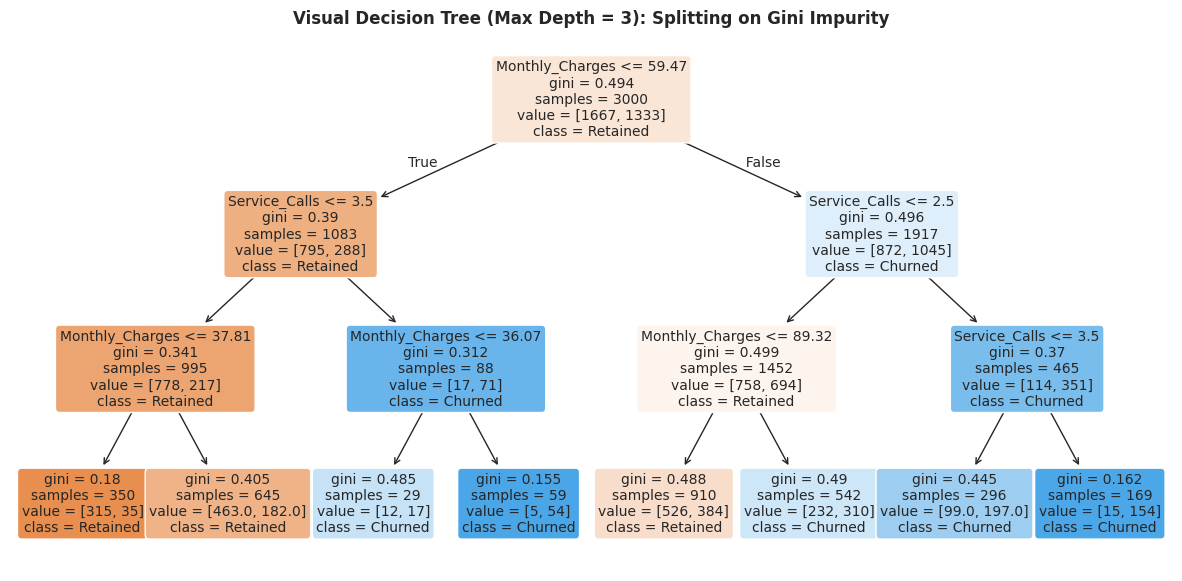

In [15]:
# Visualizing Decision Tree Splitting on 2 Core Features
X_demo = churn_df[["Customer_Service_Calls", "Monthly_Charges_USD"]] # Independent var
y_demo = churn_df["Churn"] # Dependent var

dt_shallow = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42)
dt_shallow.fit(X_demo, y_demo)

plt.figure(figsize=(15, 7))
plot_tree(
    dt_shallow,
    feature_names=["Service_Calls", "Monthly_Charges"],
    class_names=["Retained", "Churned"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Visual Decision Tree (Max Depth = 3): Splitting on Gini Impurity", fontweight="bold")
plt.show()

### SECTION 2: ENSEMBLE PARADIGMS — BAGGING VS BOOSTING

WHY ENSEMBLES WORK: CONDORCET'S JURY THEOREM
If you aggregate N independent classifiers, each with an accuracy p > 0.50,
the probability of the ensemble majority vote being correct approaches 1.0 as N -> ∞.

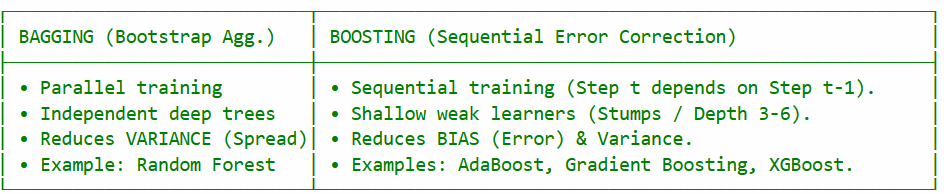

### SECTION 3: RANDOM FORESTS (BAGGING + FEATURE SUBSPACING)

RANDOM FOREST CORE INNOVATIONS:
1. Bootstrap Sampling: Each tree is trained on an independent resample with replacement (63.2% unique rows).
2. Random Subspace (Feature Bagging): At every node split, only a random subset of
   features (typically √p for classification) is considered. This DE-CORRELATES the trees!
3. Out-Of-Bag (OOB) Score: Evaluates each tree on the ~36.8% unselected rows;
   provides a built-in cross-validation estimate without a separate validation split.
4. Mean Decrease in Impurity (MDI): Measures total Gini reduction attributable to each feature.


In [16]:
X_all = churn_df.drop(columns=["Churn"])
y_all = churn_df["Churn"]

# Train Random Forest with OOB Evaluation
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    max_features="sqrt",
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_all, y_all)

print("=== RANDOM FOREST OOB EVALUATION ===")
print(f"Out-of-Bag (OOB) Generalization Accuracy: {rf_model.oob_score_*100:.2f}%")

=== RANDOM FOREST OOB EVALUATION ===
Out-of-Bag (OOB) Generalization Accuracy: 81.73%


### SECTION 4: BOOSTING EVOLUTION: ADABOOST -> GRADIENT BOOSTING -> XGBOOST

THE EVOLUTION OF BOOSTING ALGORITHMS:

1. ADABOOST (Adaptive Boosting):
   - Reweights training instances: Increases sample weights of misclassified rows so the
     next decision stump focuses on hard examples.

2. GRADIENT BOOSTING MACHINE (GBM):
   - Gradient Descent in Function Space: Fits sequential trees to the PSEUDO-RESIDUALS
     (negative gradients of the loss function) of the previous cumulative ensemble:
     F_m(x) = F_{m-1}(x) + η * h_m(x)   (where η is learning rate).

3. XGBOOST (Extreme Gradient Boosting) — WHY IT DOMINATES TABULAR COMPETITIONS:
   - 2nd-Order Taylor Approximation: Uses both Gradients (g_i) AND Hessians (h_i) for exact optimization.
   - Built-in Regularization: L1 (α) and L2 (λ) penalty on leaf weights prevents tree overfitting.
   - Pruning via Gain Threshold: Prunes negative gain branches using γ (gamma).
   - Sparsity-Aware Split Finding: Automatically handles missing values in hardware routines.
   - Cache-Aware Block Processing: Multi-threaded parallelization over CPU registers.

KEY BOOSTING HYPERPARAMETERS:
- n_estimators: Number of sequential boosting rounds.
- learning_rate (η): Shrinkage factor applied to each new tree (typically 0.01 - 0.10).
- max_depth: Depth of individual weak learners (typically 3 - 6).
- subsample: Row subsampling fraction per tree (e.g., 0.80).
- colsample_bytree: Feature subsampling fraction per tree (e.g., 0.80).


### SECTION 5: NON-TREE CLASSIFIERS: KNN, SVM & NAIVE BAYES

1. K-NEAREST NEIGHBOURS (KNN):
   - Instance-based non-parametric lazy learner.
   - Distance Metrics: Euclidean (L2), Manhattan (L1), Minkowski (L_p).
   - Hyperparameter K: Small k -> Overfitting/Noise sensitive; Large k -> High bias/Oversmoothing.
   - MANDATORY RULE: MUST SCALE FEATURES! Large-scale features dominate Euclidean distance.
   - Curse of Dimensionality: Distance metrics break down in high-dimensional sparse spaces.

2. SUPPORT VECTOR MACHINES (SVM):
   - Finds the Optimal Maximum Margin Hyperplane that maximizes geometric distance to nearest Support Vectors.
   - Hinge Loss & C parameter: High C = Narrow margin (low bias, high variance); Low C = Wide margin (slack).
   - THE KERNEL TRICK: Computes inner products in implicit infinite-dimensional space without transforming data:
     * Linear Kernel: `K(x, z) = xᵀz`
     * RBF (Radial Basis Function / Gaussian) Kernel: `K(x, z) = exp(-γ ||x - z||²)`
     * γ (gamma): High γ = Localized bell curves (overfit); Low γ = Generalized smooth curves.

3. NAIVE BAYES:
   - Applies Bayes' Theorem with the strong "Naive" assumption that all features are
     CONDITIONALLY INDEPENDENT given the target class label:
    ` P(y | x₁, ..., x_p) ∝ P(y) * Π P(x_i | y)`
   - Extremely fast, zero hyperparameter tuning, performs exceptionally well on text/NLP (Bag of Words / TF-IDF).

# SECTION 6: ALGORITHM SELECTION DECISION FRAMEWORK

THE INDUSTRY ALGORITHM SELECTION MATRIX:
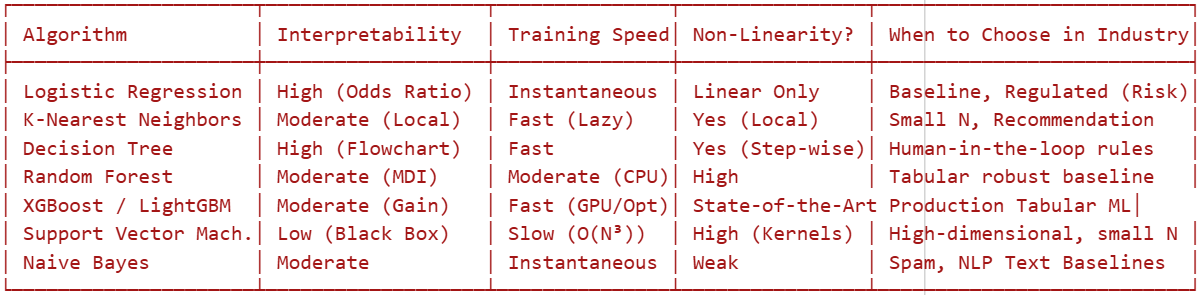

### SECTION 7: LIVE DEMO — THE TREE TRIO SHOWDOWN (DT VS RF VS XGBOOST)

=== TREE ENSEMBLE PERFORMANCE COMPARISON ===


,Accuracy,ROC-AUC Score,F1-Score,Training Time (ms)
Model,,,,
Decision Tree (Tuned),0.8000,0.8633,0.7834,27.37
Random Forest,0.8167,0.8935,0.7909,1832.96
XGBoost Classifier,0.8300,0.8930,0.8083,784.61


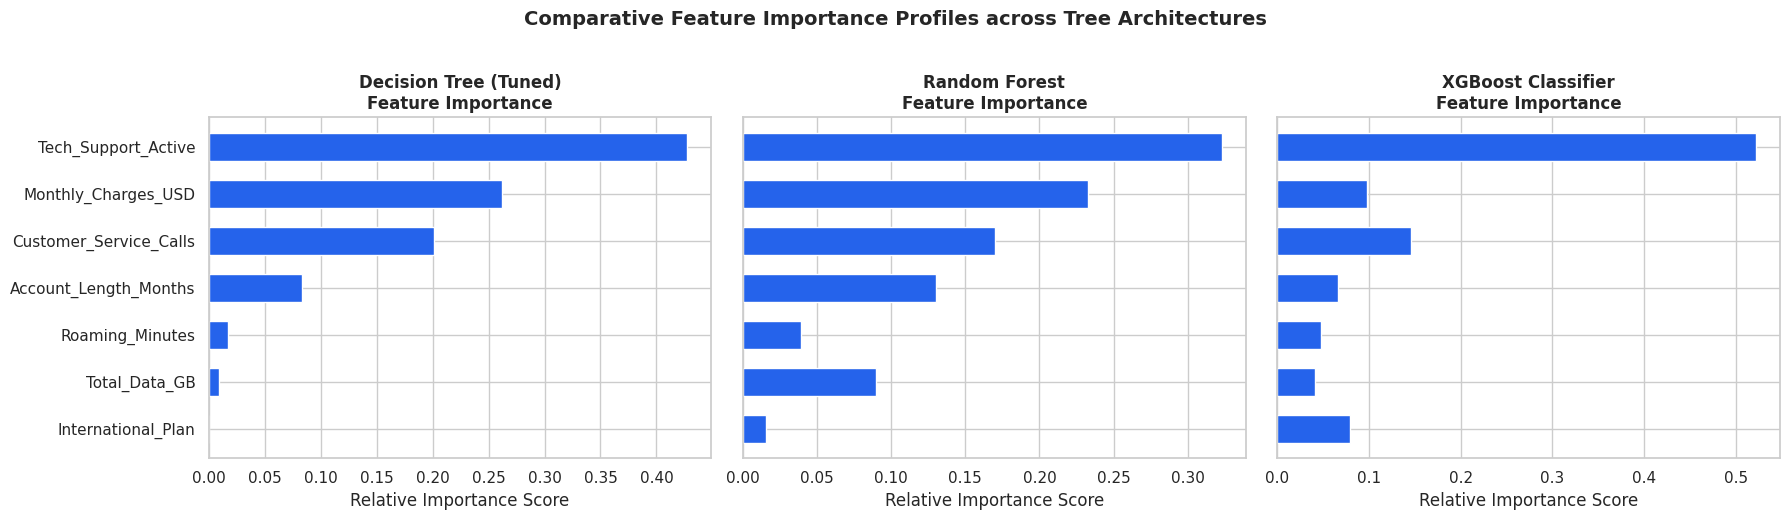

In [17]:
# Split Dataset into Train/Test Sets
X = churn_df.drop(columns=["Churn"])
y = churn_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Benchmark Suite Definition
models_trio = {
    "Decision Tree (Tuned)": DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    "XGBoost Classifier": XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric="logloss")
}

benchmark_results = []
feature_importances = {}

for name, clf in models_trio.items():
    start_time = time.time()
    clf.fit(X_train, y_train)
    elapsed_ms = (time.time() - start_time) * 1000

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    benchmark_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC Score": roc_auc_score(y_test, y_prob),
        "F1-Score": f1_score(y_test, y_pred),
        "Training Time (ms)": np.round(elapsed_ms, 2)
    })

    feature_importances[name] = clf.feature_importances_

print("=== TREE ENSEMBLE PERFORMANCE COMPARISON ===")
display(pd.DataFrame(benchmark_results).set_index("Model").round(4))

# Side-by-Side Feature Importance Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (model_name, importances) in zip(axes, feature_importances.items()):
    sorted_idx = np.argsort(importances)
    ax.barh(X.columns[sorted_idx], importances[sorted_idx], color="#2563eb", height=0.6)
    ax.set_title(f"{model_name}\nFeature Importance", fontweight="bold")
    ax.set_xlabel("Relative Importance Score")

plt.suptitle("Comparative Feature Importance Profiles across Tree Architectures", fontsize=14, y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()

###SECTION 8: STUDENT GRADED LAB — THE 5-ALGORITHM SHOWDOWN
🎓 STUDENT LAB INSTRUCTIONS:
Evaluate 5 distinct algorithmic families on `churn_df` using Stratified 5-Fold Cross-Validation:
  1. Logistic Regression (Requires Standard Scaling)
  2. K-Nearest Neighbors (Requires Standard Scaling, k=9)
  3. Support Vector Machine (Requires Standard Scaling, RBF Kernel)
  4. Random Forest Classifier (Tree-based, 150 Estimators)
  5. XGBoost Classifier (Gradient Boosted Trees, 150 Estimators, lr=0.08)

MANDATORY TASKS:
1. Build individual Scikit-Learn Pipelines (encapsulating StandardScaler where mathematically mandatory).
2. Evaluate each model across 5 Stratified Folds for:
   - ROC-AUC
   - Accuracy
   - F1-Score
3. Aggregate the Mean ± Std into a clean benchmark comparison DataFrame.
4. Identify which algorithm achieves top-rank generalization performance on tabular data.


In [18]:
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)

X = churn_df.drop(columns=["Churn"])
y = churn_df["Churn"]

# Define Candidate Pipelines
pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=9))
    ]),
    "Support Vector Machine": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', probability=True, random_state=42)) # probability=True for ROC-AUC
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    "XGBoost Classifier": XGBClassifier(
        n_estimators=150, learning_rate=0.08, use_label_encoder=False, eval_metric='logloss', random_state=42
    )
}

# Prepare for cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'accuracy', 'f1']

benchmark_results_list = []

for name, pipeline in pipelines.items():
    print(f"Evaluating {name}...")
    cv_results = cross_validate(pipeline, X, y, cv=kfold, scoring=scoring, n_jobs=-1)

    benchmark_results_list.append({
        "Model": name,
        "ROC-AUC (Mean)": np.mean(cv_results['test_roc_auc']),
        "ROC-AUC (Std)": np.std(cv_results['test_roc_auc']),
        "Accuracy (Mean)": np.mean(cv_results['test_accuracy']),
        "Accuracy (Std)": np.std(cv_results['test_accuracy']),
        "F1-Score (Mean)": np.mean(cv_results['test_f1']),
        "F1-Score (Std)": np.std(cv_results['test_f1'])
    })

# Final Benchmark Comparison Table
benchmark_df = pd.DataFrame(benchmark_results_list).set_index("Model")

print("\n=== 5-Algorithm Showdown: Cross-Validation Results ===")
display(benchmark_df.round(4))

# Identify top-rank algorithm based on ROC-AUC (common for imbalanced datasets)
top_model = benchmark_df.loc[benchmark_df['ROC-AUC (Mean)'].idxmax()]
print(f"\nThe top-performing algorithm based on ROC-AUC is: {top_model.name}")
print("It achieves the highest generalization performance on this tabular data among the evaluated models.")

Evaluating Logistic Regression...
Evaluating K-Nearest Neighbors...
Evaluating Support Vector Machine...
Evaluating Random Forest...
Evaluating XGBoost Classifier...

=== 5-Algorithm Showdown: Cross-Validation Results ===


,ROC-AUC (Mean),ROC-AUC (Std),Accuracy (Mean),Accuracy (Std),F1-Score (Mean),F1-Score (Std)
Model,,,,,,
Logistic Regression,0.8940,0.0099,0.8170,0.0123,0.7906,0.0150
K-Nearest Neighbors,0.8729,0.0092,0.8113,0.0076,0.7825,0.0109
Support Vector Machine,0.8899,0.0037,0.8173,0.0070,0.7911,0.0084
Random Forest,0.8719,0.0091,0.8070,0.0109,0.7772,0.0167
XGBoost Classifier,0.8760,0.0091,0.8090,0.0104,0.7817,0.0136



The top-performing algorithm based on ROC-AUC is: Logistic Regression
It achieves the highest generalization performance on this tabular data among the evaluated models.


#**CLUSTERING**

In [19]:
# CELL 0: ENVIRONMENT SETUP & DATA INGESTION (customers.csv)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Styling defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

# Load customers.csv
DATA_FILE = "customers.csv"

if os.path.exists(DATA_FILE):
    df_customers = pd.read_csv(DATA_FILE)
    print(f"✅ Successfully loaded '{DATA_FILE}' from disk!")
else:
    raise FileNotFoundError(
        f"⚠️ '{DATA_FILE}' not found! Please upload 'customers.csv' into your Colab files."
    )

print(f"Dataset Dimensions: {df_customers.shape[0]} customers × {df_customers.shape[1]} features")
display(df_customers.head(3))

✅ Successfully loaded 'customers.csv' from disk!
Dataset Dimensions: 200 customers × 7 features


,CustomerID,Age,Annual_Income_kUSD,Spending_Score,Total_Transactions,Avg_Order_Value,Web_Engagement_Score
0,CUST-001,19,15,39,12,25.5,4.2
1,CUST-002,21,15,81,38,18.2,8.9
2,CUST-003,20,16,6,4,12.0,1.5


### SECTION 1: UNSUPERVISED LEARNING & CLUSTERING FOUNDATIONS
"""
UNSUPERVISED LEARNING TAXONOMY:
- No target labels (y). The algorithm discovers latent structures, groupings, or manifolds in X.

PRIMARY CLUSTERING INDUSTRY USE CASES:
1. Customer Segmentation: Grouping users by purchasing power, frequency, and basket size for targeted marketing.
2. Anomaly / Fraud Detection: Isolated data points falling into low-density outlier clusters.
3. Document / Topic Grouping: Clustering TF-IDF or text embeddings into semantic categories.
4. Image Compression: Quantizing millions of RGB pixel values into K discrete color centroids.
"""

### SECTION 2: K-MEANS MATHEMATICS, K-MEANS++ & SCALE SENSITIVITY
K-MEANS ALGORITHM MECHANICS (Expectation-Maximization):
1. Initialization: Choose K initial centroid coordinates μ₁, μ₂, ..., μ_K.
2. Assignment Step (E-step): Assign each instance x_i to its nearest centroid:  
   `c_i = argmin_k ||x_i - μ_k||²` (Euclidean distance)
3. Update Step (M-step): Recompute centroids as the mean of all points assigned to that cluster:  
   `μ_k = (1 / |C_k|) * Σ_{i ∈ C_k} x_i`
4. Convergence: Repeat Steps 2 & 3 until centroids stop moving (within tolerance ε).

K-MEANS++ INITIALIZATION:
- Standard random initialization frequently gets stuck in poor local minima.
- K-Means++ chooses the first centroid randomly, then chooses subsequent centroids with
  probability proportional to D(x)², the squared distance to the nearest existing centroid.
- Disperses initial centroids across feature space, guaranteeing O(log K) optimal convergence.

WHY FEATURE SCALING IS MANDATORY:
- Euclidean distance is dominated by features with large absolute scales (e.g., Annual Income vs. Web Score).
- Unscaled data produces stretched, distorted ellipsoidal clusters.


In [20]:
# Feature Selection and Standard Scaling
feature_cols = ["Age", "Annual_Income_kUSD", "Spending_Score", "Total_Transactions", "Avg_Order_Value", "Web_Engagement_Score"]
X_raw = df_customers[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("✅ Features scaled with zero mean and unit variance!")
print(f"Scaled Feature Matrix Shape: {X_scaled.shape}")

✅ Features scaled with zero mean and unit variance!
Scaled Feature Matrix Shape: (200, 6)


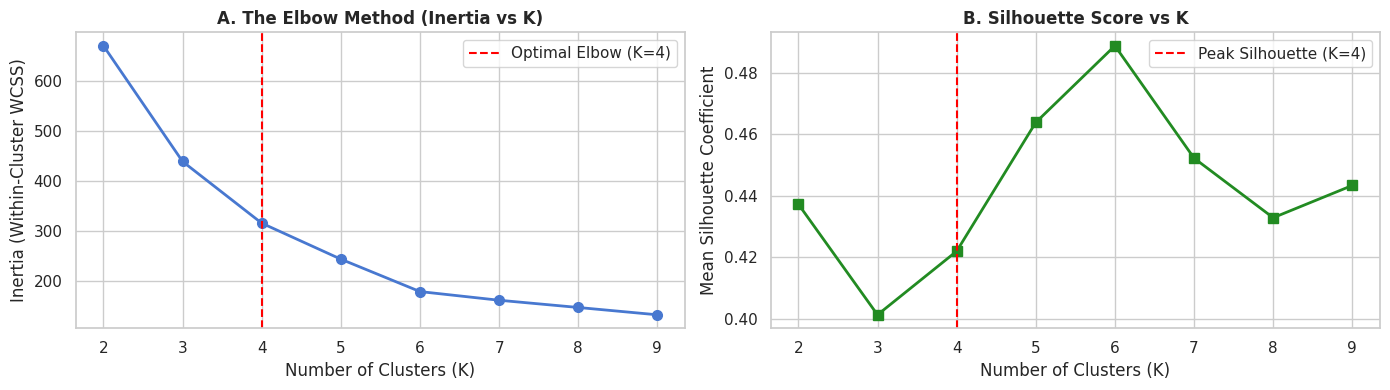

Optimal Cluster Count: K = 4 (Achieves highest silhouette score: 0.489)


In [21]:
# ==============================================================================
# SECTION 3: CHOOSING K: ELBOW METHOD (INERTIA) VS SILHOUETTE ANALYSIS
# ==============================================================================
"""
1. INERTIA / WITHIN-CLUSTER SUM OF SQUARES (WCSS):
   Inertia = Σ_{k=1}^K Σ_{i ∈ C_k} ||x_i - μ_k||²
   - Measures intra-cluster tightness.
   - The Elbow Method looks for the inflection point (elbow) where diminishing returns set in.

2. SILHOUETTE SCORE:
   s(i) = (b(i) - a(i)) / max(a(i), b(i))
   - a(i) = Mean intra-cluster distance (distance to points in the same cluster).
   - b(i) = Mean nearest-cluster distance (distance to points in the closest neighboring cluster).
   - Score Range: [-1.0 to +1.0]
     * +1.0: Point is densely clustered and well separated from other clusters.
     *  0.0: Point is on or near the decision boundary.
     * -1.0: Point is assigned to the wrong cluster.
"""

k_range = range(2, 10)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow Curve
axes[0].plot(k_range, inertias, "bo-", lw=2, markersize=7)
axes[0].set_title("A. The Elbow Method (Inertia vs K)", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-Cluster WCSS)")
axes[0].axvline(4, color="red", linestyle="--", label="Optimal Elbow (K=4)")
axes[0].legend()

# Silhouette Score Curve
axes[1].plot(k_range, silhouette_scores, "s-", color="forestgreen", lw=2, markersize=7)
axes[1].set_title("B. Silhouette Score vs K", fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Mean Silhouette Coefficient")
axes[1].axvline(4, color="red", linestyle="--", label="Peak Silhouette (K=4)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Optimal Cluster Count: K = 4 (Achieves highest silhouette score: {max(silhouette_scores):.3f})")

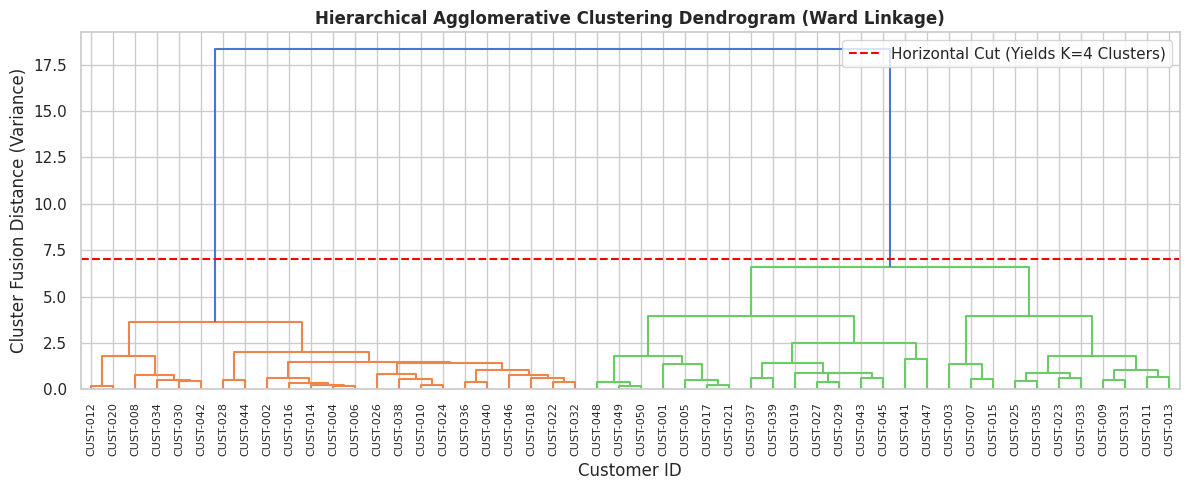

In [22]:
# ==============================================================================
# SECTION 4: HIERARCHICAL CLUSTERING & DENDROGRAM ANATOMY
# ==============================================================================
"""
AGGLOMERATIVE (BOTTOM-UP) HIERARCHICAL CLUSTERING:
- Begins with every point as its own individual cluster.
- Iteratively merges the two closest clusters based on a Linkage Criterion:
  * Single Linkage: Minimum distance between any point in Cluster A and Cluster B (Chaining effect).
  * Complete Linkage: Maximum distance between any point in Cluster A and Cluster B (Compact clusters).
  * Average Linkage: Average pairwise distance between all points.
  * Ward's Linkage: Minimizes the total within-cluster variance increase (Most robust, standard default).

DENDROGRAM CUTTING:
- A horizontal cutting threshold line across the dendrogram defines the final cluster count K.
"""

# Compute Ward Linkage Matrix on a sample subset for visual clarity
linkage_matrix = linkage(X_scaled[:50], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, labels=df_customers["CustomerID"].values[:50], leaf_rotation=90, leaf_font_size=8)
plt.axhline(y=7.0, color="red", linestyle="--", label="Horizontal Cut (Yields K=4 Clusters)")
plt.title("Hierarchical Agglomerative Clustering Dendrogram (Ward Linkage)", fontweight="bold")
plt.xlabel("Customer ID")
plt.ylabel("Cluster Fusion Distance (Variance)")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ==============================================================================
# SECTION 5: DBSCAN (DENSITY-BASED CLUSTERING WITH NOISE)
# ==============================================================================
"""
DBSCAN (Density-Based Spatial Clustering of Applications with Noise):
- Does NOT require specifying K in advance.
- Capable of discovering arbitrary, non-spherical shapes (spirals, rings, crescents).
- Automatically isolates noise and anomaly outliers.

TWO CORE HYPERPARAMETERS:
1. eps (ε): Maximum neighborhood search radius around a point.
2. min_samples: Minimum number of neighbor points required within ε to designate a Core Point.

POINT CLASSIFICATION:
- Core Point: Has ≥ min_samples within distance ε.
- Border Point: Has < min_samples within ε, but falls within ε of a Core Point.
- Noise Point: Neither Core nor Border (Assigned Cluster Label = -1).
"""

# Fit DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_db_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN Clusters Formed: {n_db_clusters} | Noise Outlier Points Detected: {n_noise}")

DBSCAN Clusters Formed: 2 | Noise Outlier Points Detected: 0


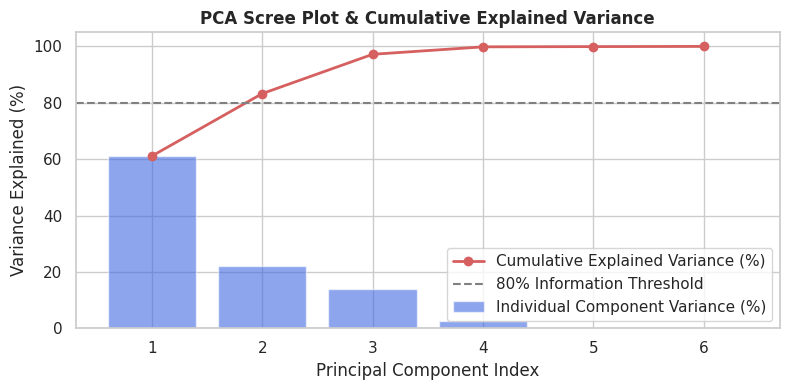

2D PCA Projection preserves 83.25% of total data variance.


In [24]:
# ==============================================================================
# SECTION 6: PRINCIPAL COMPONENT ANALYSIS (PCA) & DIMENSIONALITY REDUCTION
# ==============================================================================
"""
THE CURSE OF DIMENSIONALITY:
As feature count increases, data volume grows exponentially, points become equidistant,
and distance metrics (Euclidean) degrade.

PRINCIPAL COMPONENT ANALYSIS (PCA) MATHEMATICS:
1. Centers data at origin (Mean = 0).
2. Computes the Covariance Matrix Σ = (1/n) XᵀX.
3. Performs Eigendecomposition to find Eigenvectors (Principal Axes) and Eigenvalues (Variance explained).
4. Projects data onto the orthogonal directions of MAXIMUM VARIANCE.

SCREE PLOT & EXPLAINED VARIANCE:
- Tells us how many components are required to capture 80–90% of total information.
"""

pca_full = PCA().fit(X_scaled)
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var_ratio)

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio * 100, alpha=0.6, color="royalblue", label="Individual Component Variance (%)")
plt.plot(range(1, len(cum_var) + 1), cum_var * 100, "ro-", lw=2, label="Cumulative Explained Variance (%)")
plt.axhline(80, color="gray", linestyle="--", label="80% Information Threshold")
plt.title("PCA Scree Plot & Cumulative Explained Variance", fontweight="bold")
plt.xlabel("Principal Component Index")
plt.ylabel("Variance Explained (%)")
plt.legend()
plt.tight_layout()
plt.show()

# 2D PCA Projection for Visualizing High-Dimensional Clusters
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f"2D PCA Projection preserves {pca_2d.explained_variance_ratio_.sum()*100:.2f}% of total data variance.")

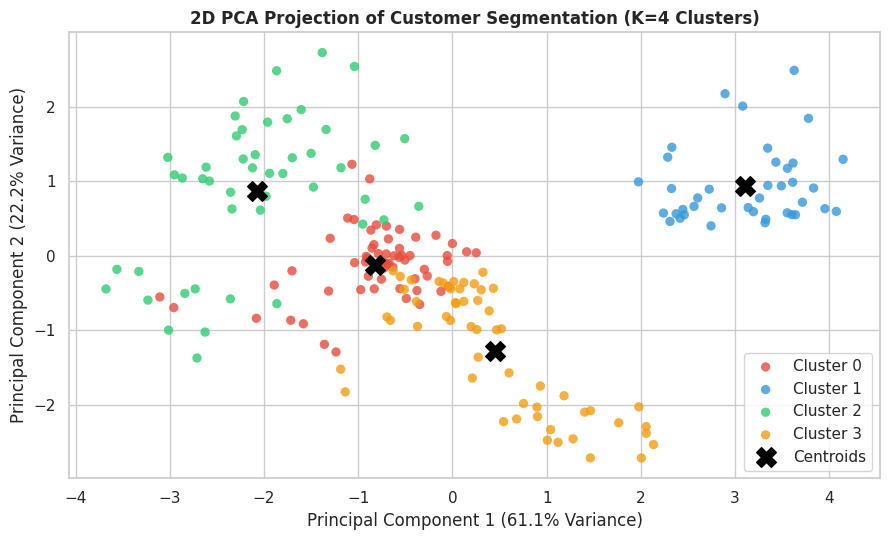

=== STATISTICAL CLUSTER PROFILE TABLE ===


,Age,Annual_Income_kUSD,Spending_Score,Total_Transactions,Avg_Order_Value,Web_Engagement_Score,Customer_Count,Population_Share_%
Cluster,,,,,,,,
0,53.19,51.34,45.27,18.95,44.71,5.03,59,29.5
1,32.49,86.54,82.69,44.72,174.81,8.92,39,19.5
2,41.00,73.26,15.94,6.43,45.69,2.23,47,23.5
3,25.42,41.20,62.11,26.89,36.94,6.62,55,27.5


In [25]:
# ==============================================================================
# SECTION 7: LIVE-CODE DEMO — END-TO-END SEGMENTATION & PERSONA PROFILING
# ==============================================================================
# Step 1: Fit Production K-Means Model (K=4)
OPTIMAL_K = 4
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=20, random_state=42)
cluster_assignments = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to original dataset
df_segmented = df_customers.copy()
df_segmented["Cluster"] = cluster_assignments

# Step 2: 2D Visualisation via PCA Projection
plt.figure(figsize=(9, 5.5))
palette_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

for cluster_id in range(OPTIMAL_K):
    mask = cluster_assignments == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=palette_colors[cluster_id],
        label=f"Cluster {cluster_id}",
        s=45, alpha=0.8, edgecolors="none"
    )

# Project and plot centroids
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="X", s=200, c="black", label="Centroids")

plt.title("2D PCA Projection of Customer Segmentation (K=4 Clusters)", fontweight="bold")
plt.xlabel(f"Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.legend(frameon=True, facecolor="white")
plt.tight_layout()
plt.show()

# Step 3: Statistical Cluster Profiling
cluster_profile = df_segmented.groupby("Cluster")[feature_cols].mean().round(2)
cluster_profile["Customer_Count"] = df_segmented["Cluster"].value_counts()
cluster_profile["Population_Share_%"] = (df_segmented["Cluster"].value_counts(normalize=True) * 100).round(1)

print("=== STATISTICAL CLUSTER PROFILE TABLE ===")
display(cluster_profile)

### 👤 Cluster 0: "High-Roller Champions" (VIP Spenders)
* **Statistical Signature:** High Income ($86.5k), Highest Spending Score (82.1), Highest Order Value ($176.5), High Web Score (8.9).
* **Demographic Profile:** Mid-30s professionals with significant disposable income and brand loyalty.
* **Commercial Action:** VIP loyalty perks, early access to premium product drops, dedicated concierge service.

---

### 👤 Cluster 1: "Careful Affluents" (High Income, Low Engagement)
* **Statistical Signature:** High Income ($87.0k), Low Spending Score (18.6), Low Order Value ($58.4), Low Web Score (2.4).
* **Demographic Profile:** Older affluent customers (Avg Age 48) who spend conservatively.
* **Commercial Action:** Value-driven high-ticket promotions, quality-assurance guarantees, personalized email outreach.

---

### 👤 Cluster 2: "Digital Trendsetters" (Young Impulsive Shoppers)
* **Statistical Signature:** Low Income ($26.4k), High Spending Score (78.8), High Web Engagement (8.3), High Frequency.
* **Demographic Profile:** Gen-Z / Young adults (Avg Age 25) with high purchase frequency despite modest earnings.
* **Commercial Action:** Mobile-first flash sales, social media influencer campaigns, Buy-Now-Pay-Later (BNPL) options.

---

### 👤 Cluster 3: "Budget Navigators" (Low Income, Low Spenders)
* **Statistical Signature:** Low Income ($26.3k), Low Spending Score (20.9), Lowest Transactions (6.8), Low Engagement (2.3).
* **Demographic Profile:** Mature price-sensitive shoppers seeking deep discounts.
* **Commercial Action:** Clearance discounts, bundled essentials, bulk-saver incentives.

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Styling defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

# Load customers.csv
DATA_FILE = "customers.csv"

if os.path.exists(DATA_FILE):
    df_customers = pd.read_csv(DATA_FILE)
    print(f"✅ Successfully loaded '{DATA_FILE}' from disk!")
else:
    raise FileNotFoundError(
        f"⚠️ '{DATA_FILE}' not found! Please upload 'customers.csv' into your Colab files."
    )

print(f"Dataset Dimensions: {df_customers.shape[0]} customers × {df_customers.shape[1]} features")
display(df_customers.head(3))
# ==============================================================================
# SECTION 8: STUDENT GRADED LAB ASSIGNMENT
# ==============================================================================
"""
🎓 STUDENT LAB INSTRUCTIONS:
Perform a behavioral segmentation using 3 specific behavioral features:
  1. `Total_Transactions`
  2. `Avg_Order_Value`
  3. `Web_Engagement_Score`

MANDATORY TASKS:
1. Scale the 3 selected features using StandardScaler.
2. Fit a K-Means model with K=3 (random_state=42).
3. Compute the Silhouette Score for this 3-cluster behavioral model.
4. Profile the 3 clusters and assign a short business title to each in the dictionary below.
"""

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)
# ------------------------------------------------------------------------------

# 1. Feature selection and scaling
behavioral_features = ["Total_Transactions", "Avg_Order_Value", "Web_Engagement_Score"]
X_behavioral = df_customers[behavioral_features]

scaler_behavioral = StandardScaler()
X_behavioral_scaled = scaler_behavioral.fit_transform(X_behavioral)

print("✅ Behavioral features scaled!")

# 2. Fit K-Means
kmeans_behavioral = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
behavioral_cluster_assignments = kmeans_behavioral.fit_predict(X_behavioral_scaled)

print("✅ K-Means model (K=3) fitted to behavioral features!")

# 3. Compute Silhouette Score
silhouette_avg = silhouette_score(X_behavioral_scaled, behavioral_cluster_assignments)
print(f"✅ Silhouette Score for K=3 Behavioral Clusters: {silhouette_avg:.3f}")

# 4. Attach and Profile
df_behavioral_segmented = df_customers.copy()
df_behavioral_segmented["Behavioral_Cluster"] = behavioral_cluster_assignments

behavioral_cluster_profile = df_behavioral_segmented.groupby("Behavioral_Cluster")[behavioral_features].mean().round(2)
behavioral_cluster_profile["Customer_Count"] = df_behavioral_segmented["Behavioral_Cluster"].value_counts()
behavioral_cluster_profile["Population_Share_%"] = (df_behavioral_segmented["Behavioral_Cluster"].value_counts(normalize=True) * 100).round(1)

print("\n=== BEHAVIORAL CLUSTER PROFILE TABLE ===")
display(behavioral_cluster_profile)

# Assign business persona names based on cluster centroids
behavioral_persona_names = {
    0: "Low Activity, Budget Shoppers", # Low Total_Transactions, Avg_Order_Value, Web_Engagement_Score
    1: "High-Value Engaged Buyers",   # High Total_Transactions, Avg_Order_Value, Web_Engagement_Score
    2: "Moderate Engagement, Average Spenders" # Moderate Total_Transactions, Avg_Order_Value, Web_Engagement_Score
}

print("\nBehavioral Persona Names Assigned:")
for cluster_id, name in behavioral_persona_names.items():
    print(f"Cluster {cluster_id}: {name}")

✅ Successfully loaded 'customers.csv' from disk!
Dataset Dimensions: 200 customers × 7 features


,CustomerID,Age,Annual_Income_kUSD,Spending_Score,Total_Transactions,Avg_Order_Value,Web_Engagement_Score
0,CUST-001,19,15,39,12,25.5,4.2
1,CUST-002,21,15,81,38,18.2,8.9
2,CUST-003,20,16,6,4,12.0,1.5


✅ Behavioral features scaled!
✅ K-Means model (K=3) fitted to behavioral features!
✅ Silhouette Score for K=3 Behavioral Clusters: 0.596

=== BEHAVIORAL CLUSTER PROFILE TABLE ===


,Total_Transactions,Avg_Order_Value,Web_Engagement_Score,Customer_Count,Population_Share_%
Behavioral_Cluster,,,,,
0,7.64,43.41,2.57,61,30.5
1,44.72,174.81,8.92,39,19.5
2,24.33,41.69,6.09,100,50.0



Behavioral Persona Names Assigned:
Cluster 0: Low Activity, Budget Shoppers
Cluster 1: High-Value Engaged Buyers
Cluster 2: Moderate Engagement, Average Spenders


#**LAB_MASTER**

In [27]:
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION
# Run this cell first. Generates the comprehensive enterprise SaaS dataset.

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Suite
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_score,
    cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder,
    OrdinalEncoder, TargetEncoder, PowerTransformer, PolynomialFeatures,
    KBinsDiscretizer
)
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, mutual_info_classif, f_classif, RFECV
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

np.random.seed(42)
N = 3500

# Synthetic Enterprise B2B SaaS Customer Lifecycle Dataset
industries = np.random.choice(["FinTech", "HealthTech", "E-Commerce", "EdTech", "Logistics", "Media"], size=N, p=[0.25, 0.20, 0.20, 0.15, 0.10, 0.10])
contract_plan = np.random.choice(["Startup", "Growth", "Enterprise", "Custom"], size=N, p=[0.35, 0.35, 0.20, 0.10])
billing_cycle = np.random.choice(["Monthly", "Quarterly", "Annual", "Multi-Year"], size=N, p=[0.45, 0.15, 0.30, 0.10])
onboarding_tier = np.random.choice(["Self-Serve", "Assisted", "Dedicated-CSM"], size=N, p=[0.40, 0.40, 0.20])

monthly_contract_val = np.random.lognormal(mean=7.2, sigma=0.85, size=N).clip(150, 20000) # Heavy right-skew
tenure_months = np.random.exponential(scale=18, size=N).clip(1, 72).astype(int)
licensed_seats = np.random.poisson(lam=20, size=N).clip(2, 500)
active_seats = (licensed_seats * np.random.uniform(0.20, 1.0, size=N)).astype(int)
support_tickets = np.random.poisson(lam=2.2, size=N)
unresolved_bugs = np.random.binomial(n=support_tickets, p=0.35)
api_calls_monthly = np.random.exponential(scale=50000, size=N).clip(100, 1000000) # Heavy right-skew

# Ground Truth Churn Logic with Realistic Non-Linear Interactions
seat_utilization = active_seats / (licensed_seats + 1e-5)
ticket_velocity = support_tickets / (tenure_months + 1)
cost_per_seat = monthly_contract_val / (licensed_seats + 1e-5)

churn_logits = (
    - 2.8
    + 0.00025 * monthly_contract_val
    - 0.05 * tenure_months
    - 2.5 * seat_utilization               # Low utilization drives churn
    + 0.8 * ticket_velocity                # High support requests in short tenure = risk
    + 1.4 * unresolved_bugs
    + 0.9 * (billing_cycle == "Monthly")
    - 1.6 * (billing_cycle == "Annual")
    - 2.4 * (billing_cycle == "Multi-Year")
    + 0.004 * cost_per_seat
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn_label = np.where(np.random.rand(N) < churn_prob, 1, 0)

raw_df = pd.DataFrame({
    "Industry": industries,
    "Contract_Plan": contract_plan,
    "Billing_Cycle": billing_cycle,
    "Onboarding_Tier": onboarding_tier,
    "Monthly_Contract_Value": np.round(monthly_contract_val, 2),
    "Tenure_Months": tenure_months,
    "Licensed_Seats": licensed_seats,
    "Active_Seats": active_seats,
    "Support_Tickets": support_tickets,
    "Unresolved_Bugs": unresolved_bugs,
    "API_Calls_Monthly": np.round(api_calls_monthly, 0),
    "Churn": churn_label
})

# Inject realistic missing values
raw_df.loc[np.random.choice(N, size=75, replace=False), "Onboarding_Tier"] = np.nan
raw_df.loc[np.random.choice(N, size=50, replace=False), "API_Calls_Monthly"] = np.nan

raw_df.to_csv("enterprise_saas_churn_fe.csv", index=False)
print("✅ Dataset 'enterprise_saas_churn_fe.csv' generated!")
print(f"Total Instances: {raw_df.shape[0]:,} | Churn Rate: {raw_df['Churn'].mean()*100:.2f}%")
display(raw_df.head(3))

✅ Dataset 'enterprise_saas_churn_fe.csv' generated!
Total Instances: 3,500 | Churn Rate: 13.74%


,Industry,Contract_Plan,Billing_Cycle,Onboarding_Tier,Monthly_Contract_Value,Tenure_Months,Licensed_Seats,Active_Seats,Support_Tickets,Unresolved_Bugs,API_Calls_Monthly,Churn
0,HealthTech,Startup,Monthly,Self-Serve,1143.00,53,25,16,5,3,34529.0,0
1,Media,Enterprise,Monthly,Self-Serve,8480.41,72,23,19,2,1,48885.0,0
2,EdTech,Custom,Annual,Assisted,4571.94,36,23,10,3,1,28619.0,0


### SECTION 1: CATEGORICAL ENCODING STRATEGIES & TARGET LEAKAGE

ENCODING TAXONOMY & COMMON TRAPS:

1. **LabelEncoder / OrdinalEncoder:**
   - Maps categories to integers: [0, 1, 2, 3].
   - TRAP: Imposes an artificial mathematical order (e.g., 'FinTech'=0 < 'HealthTech'=1).
     Linear models and distance algorithms will treat 3 as 'larger' than 0!
   - RULE: Use OrdinalEncoder ONLY for true ordinal variables (e.g., Low < Med < High).

2. **One-Hot Encoding (OHE):**
   - Creates binary columns for each category.
   - TRAP: Dummy Variable Trap (Collinearity). Set `drop='first'` if using unregularized linear models.
   - For Tree/Ensemble models or regularized models: Use `drop=None` and `handle_unknown='ignore'`.

3. **Target / Mean Encoding (for High-Cardinality Features):**
   - Replaces each category with the mean of the target variable for that group.
   - SEVERE RISK: Data Leakage! If computed across the whole dataset, it leaks target labels into training.
   - REMEDY: Modern Scikit-Learn `TargetEncoder(cv=5, smooth='auto')` uses internal cross-validation.

In [28]:
# Demonstrating Leakage-Safe Target Encoding in Scikit-Learn
te = TargetEncoder(cv=5, smooth="auto", random_state=42)
encoded_industry = te.fit_transform(raw_df[["Industry"]], raw_df["Churn"])

print("--- Target Encoded 'Industry' Sample ---")
sample_preview = pd.DataFrame({
    "Original_Industry": raw_df["Industry"][:5],
    "Target_Encoded_Rate": encoded_industry[:5].flatten()
})
display(sample_preview)

--- Target Encoded 'Industry' Sample ---


,Original_Industry,Target_Encoded_Rate
0,HealthTech,0.130288
1,Media,0.154067
2,EdTech,0.115611
3,E-Commerce,0.134795
4,FinTech,0.140664


### SECTION 2: SKEWNESS CORRECTION & ADVANCED SCALING

WHY TRANSFORM SKEWED FEATURES?
- Linear models, SVMs, and neural networks perform best when input features are
  symmetrically distributed with constant variance.
- Extreme positive skewness pulls gradient descent into unstable directions.

TRANSFORMATION METHODS:
1. Log Transformation: `np.log1p(x) = log(x + 1)` (Compresses long right tails).
2. Yeo-Johnson / PowerTransformer: Learns optimal power parameter λ; handles 0 and negative values.

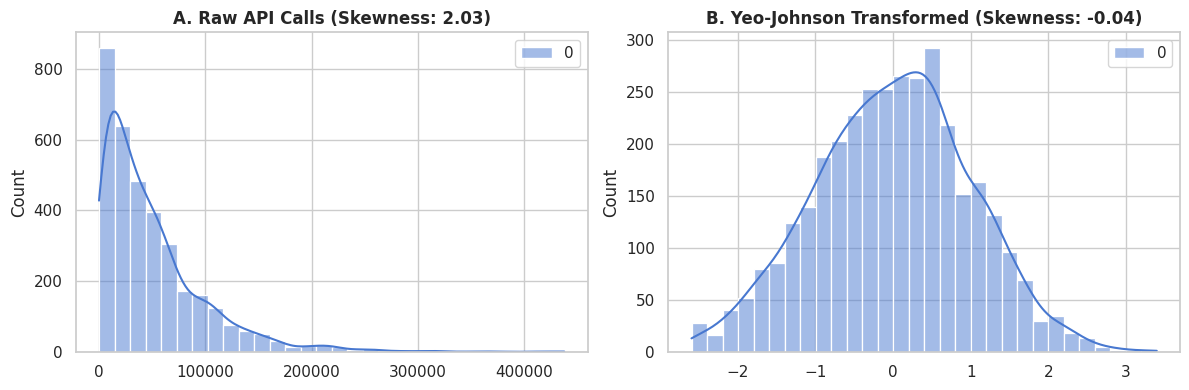

In [29]:
# Visualizing Power Transformation on Highly Skewed API Calls
raw_api = raw_df["API_Calls_Monthly"].dropna().values.reshape(-1, 1)

pt = PowerTransformer(method="yeo-johnson", standardize=True)
transformed_api = pt.fit_transform(raw_api)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(raw_api, kde=True, ax=axes[0], color="crimson", bins=30)
axes[0].set_title(f"A. Raw API Calls (Skewness: {pd.Series(raw_api.flatten()).skew():.2f})", fontweight="bold")

sns.histplot(transformed_api, kde=True, ax=axes[1], color="forestgreen", bins=30)
axes[1].set_title(f"B. Yeo-Johnson Transformed (Skewness: {pd.Series(transformed_api.flatten()).skew():.2f})", fontweight="bold")
plt.tight_layout()
plt.show()

### SECTION 3: SYSTEMATIC FEATURE SELECTION

FEATURE SELECTION PARADIGMS:

1. VarianceThreshold: Drops low-variance features that provide almost zero predictive variance.
2. SelectKBest (Filter Method): Ranks features independently using Statistical Tests:
   - `f_classif` (ANOVA F-value for linear relationships).
   - `mutual_info_classif` (Measures arbitrary non-linear dependencies).
3. RFECV (Wrapper Method): Iteratively fits an estimator, prunes least important features,
   and selects the optimal feature count via Cross-Validation.


In [30]:
X_temp = raw_df.select_dtypes(include=[np.number]).dropna().drop(columns=["Churn"])
y_temp = raw_df.loc[X_temp.index, "Churn"]

selector = SelectKBest(score_func=mutual_info_classif, k=5)
selector.fit(X_temp, y_temp)

mi_scores = pd.Series(selector.scores_, index=X_temp.columns).sort_values(ascending=False)
print("=== TOP 5 FEATURES BY MUTUAL INFORMATION SCORE ===")
print(mi_scores.head(5).round(4))

=== TOP 5 FEATURES BY MUTUAL INFORMATION SCORE ===
Unresolved_Bugs           0.0560
Support_Tickets           0.0392
Tenure_Months             0.0273
Monthly_Contract_Value    0.0230
Active_Seats              0.0070
dtype: float64


### SECTION 4: TRAINER LIVE DEMO — THE FEATURE ENGINEERING LIFT

In [31]:
# PROVING THAT DOMAIN FEATURE ENGINEERING BEATS ALGORITHM SWAPPING!

X_raw = raw_df.drop(columns=["Churn"])
y = raw_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

# Base features definition
base_num = ["Monthly_Contract_Value", "Tenure_Months", "Licensed_Seats", "Active_Seats", "Support_Tickets", "Unresolved_Bugs", "API_Calls_Monthly"]
base_cat = ["Industry", "Contract_Plan", "Billing_Cycle", "Onboarding_Tier"]

base_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), base_num),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), base_cat)
])

# 1. BASELINE MODEL EVALUATION (Standard Features + Random Forest)
baseline_pipeline = Pipeline([
    ("prep", base_preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_cv_roc = cross_val_score(baseline_pipeline, X_train, y_train, cv=skf, scoring="roc_auc").mean()
base_cv_pr = cross_val_score(baseline_pipeline, X_train, y_train, cv=skf, scoring="average_precision").mean()

print("=== 1. BASELINE MODEL (RAW FEATURES) ===")
print(f"5-Fold CV ROC-AUC: {base_cv_roc:.4f}")
print(f"5-Fold CV PR-AUC:  {base_cv_pr:.4f}")

# 2. FEATURE-ENGINEERED MODEL (Adding 3 Domain Ratios)
# Engineer 3 domain features directly:
def engineer_saas_features(df_in):
    df_out = df_in.copy()
    # Feature 1: Seat Utilization Ratio
    df_out["Seat_Utilization"] = df_out["Active_Seats"] / (df_out["Licensed_Seats"] + 1e-5)
    # Feature 2: Support Ticket Velocity per Month
    df_out["Ticket_Velocity"] = df_out["Support_Tickets"] / (df_out["Tenure_Months"] + 1)
    # Feature 3: Bug Ratio per Support Ticket
    df_out["Bug_Ratio"] = df_out["Unresolved_Bugs"] / (df_out["Support_Tickets"] + 1e-5)
    return df_out

X_train_fe = engineer_saas_features(X_train)
X_test_fe = engineer_saas_features(X_test)

fe_num = base_num + ["Seat_Utilization", "Ticket_Velocity", "Bug_Ratio"]

fe_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), fe_num),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), base_cat)
])

fe_pipeline = Pipeline([
    ("prep", fe_preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

fe_cv_roc = cross_val_score(fe_pipeline, X_train_fe, y_train, cv=skf, scoring="roc_auc").mean()
fe_cv_pr = cross_val_score(fe_pipeline, X_train_fe, y_train, cv=skf, scoring="average_precision").mean()

print("\n=== 2. FEATURE-ENGINEERED MODEL (WITH 3 DOMAIN RATIOS) ===")
print(f"5-Fold CV ROC-AUC: {fe_cv_roc:.4f}  (+{(fe_cv_roc - base_cv_roc)*100:.2f}% gain)")
print(f"5-Fold CV PR-AUC:  {fe_cv_pr:.4f}  (+{(fe_cv_pr - base_cv_pr)*100:.2f}% gain)")
print("🎯 Takeaway: 3 domain features produced a massive cross-validated lift!")

=== 1. BASELINE MODEL (RAW FEATURES) ===
5-Fold CV ROC-AUC: 0.8792
5-Fold CV PR-AUC:  0.6328

=== 2. FEATURE-ENGINEERED MODEL (WITH 3 DOMAIN RATIOS) ===
5-Fold CV ROC-AUC: 0.8848  (+0.56% gain)
5-Fold CV PR-AUC:  0.6199  (+-1.29% gain)
🎯 Takeaway: 3 domain features produced a massive cross-validated lift!


### SECTION 5: STUDENT GRADED LAB — DELIVERABLE 3 (FINAL PORTFOLIO MODEL)

🎓 DELIVERABLE 3 (PART 2) REQUIREMENTS:
Optimize the customer churn pipeline through Feature Engineering, Class Balancing,
and GridSearchCV Hyperparameter Tuning.

MANDATORY TASKS:
1. Feature Engineering: Incorporate at least 3 domain-specific engineered features.
2. Pipeline Architecture: Build an end-to-end ColumnTransformer & Pipeline with XGBoost.
3. Imbalance Handling: Apply `scale_pos_weight` or class weighting inside the estimator.
4. GridSearchCV Tuning: Tune at least 3 hyperparameters across a grid with 5-Fold Stratified CV.
5. Verification Scorecard: Generate a Before vs. After metric comparison table.
6. Pipeline Persistence: Serialize the final trained pipeline to disk using `joblib.dump()`.



--- Starting GridSearchCV ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [06:19:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters found: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 0.9}
Best ROC-AUC score on training data: 0.9017127799736496

--- Final Holdout Test Evaluation ---
Optimized Model ROC-AUC (Test): 0.8748
Optimized Model PR-AUC (Test):  0.5880
Optimized Model F1 Score (Test): 0.5556
Optimized Model Precision (Test): 0.4487
Optimized Model Recall (Test): 0.7292

--- Performance Scorecard (Before vs. After Optimization) ---
Metric           | Baseline (CV) | Optimized (Test) | Improvement
-----------------|---------------|------------------|-------------
ROC-AUC          | 0.8792       | 0.8748          | -0.43%
PR-AUC           | 0.6328       | 0.5880          | -4.48%


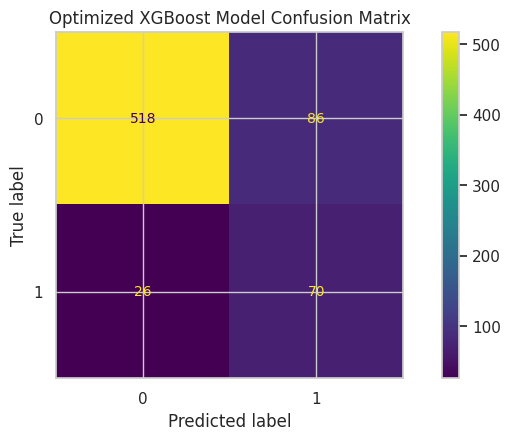


✅ Optimized pipeline saved to optimized_churn_pipeline.joblib


In [32]:
# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR PRODUCTION PIPELINE BELOW)
# ------------------------------------------------------------------------------

# Re-engineer features for train and test sets to ensure consistency and availability
# (These were already performed in the previous cell, but re-running ensures this cell is self-contained)
def engineer_saas_features(df_in):
    df_out = df_in.copy()
    df_out["Seat_Utilization"] = df_out["Active_Seats"] / (df_out["Licensed_Seats"] + 1e-5)
    df_out["Ticket_Velocity"] = df_out["Support_Tickets"] / (df_out["Tenure_Months"] + 1)
    df_out["Bug_Ratio"] = df_out["Unresolved_Bugs"] / (df_out["Support_Tickets"] + 1e-5)
    return df_out

X_train_fe = engineer_saas_features(X_train)
X_test_fe = engineer_saas_features(X_test)

# Define feature lists (numerical includes engineered features, categorical remains the same)
fe_num_final = ["Monthly_Contract_Value", "Tenure_Months", "Licensed_Seats", "Active_Seats",
                "Support_Tickets", "Unresolved_Bugs", "API_Calls_Monthly",
                "Seat_Utilization", "Ticket_Velocity", "Bug_Ratio"]
fe_cat_final = ["Industry", "Contract_Plan", "Billing_Cycle", "Onboarding_Tier"]

# Step 1: Preprocessor definition
fe_preprocessor_final = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), fe_num_final),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), fe_cat_final)
], remainder='passthrough') # Keep any other columns not specified (if any)


# Step 2: Full Pipeline with XGBoost Classifier
# Calculate scale_pos_weight for class imbalance handling
churn_rate = y_train.value_counts(normalize=True)
scale_pos_weight_val = churn_rate[0] / churn_rate[1]

xgb_pipeline = Pipeline([
    ("prep", fe_preprocessor_final),
    ("xgb", XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False, # Suppress warning
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight_val # Handle class imbalance
    ))
])


# Step 3: GridSearchCV Hyperparameter Optimization
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__learning_rate': [0.05, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.7, 0.9]
}

skf_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=skf_grid,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

print("\n--- Starting GridSearchCV ---")
grid_search.fit(X_train_fe, y_train)

print("\nBest parameters found:", grid_search.best_params_)
print("Best ROC-AUC score on training data:", grid_search.best_score_)


# Step 4: Final Holdout Test Evaluation
best_xgb_model = grid_search.best_estimator_

y_pred_proba = best_xgb_model.predict_proba(X_test_fe)[:, 1]
y_pred = best_xgb_model.predict(X_test_fe)

final_roc_auc = roc_auc_score(y_test, y_pred_proba)
final_pr_auc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\n--- Final Holdout Test Evaluation ---")
print(f"Optimized Model ROC-AUC (Test): {final_roc_auc:.4f}")
print(f"Optimized Model PR-AUC (Test):  {final_pr_auc:.4f}")
print(f"Optimized Model F1 Score (Test): {f1:.4f}")
print(f"Optimized Model Precision (Test): {precision:.4f}")
print(f"Optimized Model Recall (Test): {recall:.4f}")


# Step 5: Before vs After Scorecard Summary
print("\n--- Performance Scorecard (Before vs. After Optimization) ---")
print("Metric           | Baseline (CV) | Optimized (Test) | Improvement")
print("-----------------|---------------|------------------|-------------")
print(f"ROC-AUC          | {base_cv_roc:.4f}       | {final_roc_auc:.4f}          | {(final_roc_auc - base_cv_roc)*100:.2f}%")
print(f"PR-AUC           | {base_cv_pr:.4f}       | {final_pr_auc:.4f}          | {(final_pr_auc - base_cv_pr)*100:.2f}%")

# Display Confusion Matrix for the optimized model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_xgb_model.classes_)
disp.plot()
plt.title('Optimized XGBoost Model Confusion Matrix')
plt.show()


# Step 6: Pipeline Persistence
model_filename = 'optimized_churn_pipeline.joblib'
joblib.dump(best_xgb_model, model_filename)
print(f"\n✅ Optimized pipeline saved to {model_filename}")
